In [63]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
from torch import nn

In [64]:
train_data = MNIST(
    root='data',
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = MNIST(
    root='data',
    train=False,
    download=True,
    transform=ToTensor()
)

In [65]:
img, label = train_data[0]
img.shape, len(train_data)

(torch.Size([1, 28, 28]), 60000)

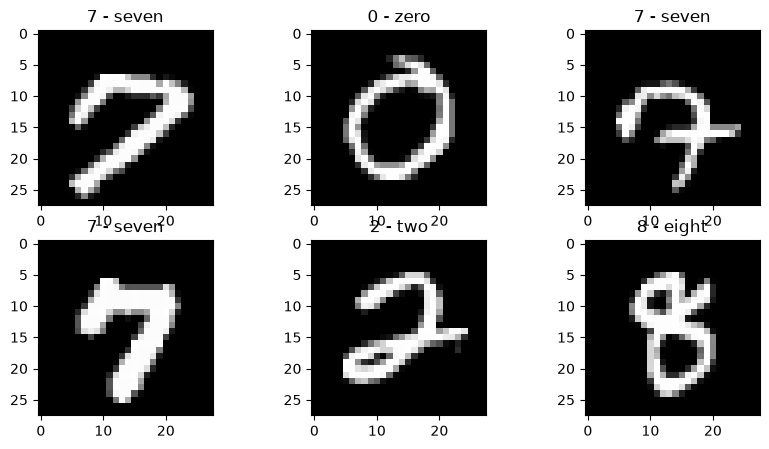

In [66]:
class_names = train_data.classes
plt.figure(figsize=(10,5))
cols = 3
rows = 2

for i in range(cols * rows):
    rand_int = torch.randint(low=0, high=len(train_data), size=[1]).item()
    img, label = train_data[rand_int]
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])

In [67]:
train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=32)


In [68]:
class MNISTClassifierV0(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()
        self.layer_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer_3 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7, out_features=output_shape)
        )
    def forward(self, x):
        x = self.layer_1(x)
        x = self.layer_2(x)
        x = self.layer_3(x)
        return x

model_0 = MNISTClassifierV0(input_shape=1, hidden_units=10, output_shape=len(class_names))

In [69]:
device = 'cpu'

def print_train_time(start: float, end: float, device: torch.device = None):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

def training_step(model: nn.Module, loss_fn:torch.nn.Module, accuracy_fn, optimizer:torch.optim.Optimizer, training_data:torch.utils.data.DataLoader, device=device):
    model.train()
    model.to(device)
    training_acc, training_loss = 0, 0
    for X, y in training_data:
        X = X.to(device)
        y = y.to(device)
        y_logits = model(X)
        loss = loss_fn(y_logits, y)
        training_loss += loss.item()
        y_pred = y_logits.argmax(dim=1)
        training_acc += accuracy_fn(y, y_pred)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    training_loss /= len(training_data)
    training_acc /= len(training_data)
    print(f"Train loss: {training_loss:.5f} | Train accuracy: {training_acc:.2f}%")


def testing_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval()
    with torch.inference_mode(): 
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            test_pred = model(X)
            test_loss += loss_fn(test_pred, y).item()
            test_acc += accuracy_fn(y_true=y,
                y_pred=test_pred.argmax(dim=1)
            )
    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

In [70]:
from helper_functions import accuracy_fn
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)


In [71]:
from timeit import default_timer as timer

start_time = timer()
epochs = 3
for epoch in range(epochs):
    training_step(model=model_0, training_data=train_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn, optimizer=optimizer)
    testing_step(model=model_0, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn)
end_time = timer()
cpu_time = print_train_time(start=start_time, end=end_time, device=device)


Train loss: 2.30125 | Train accuracy: 11.21%
Test loss: 2.29875 | Test accuracy: 11.35%

Train loss: 1.28924 | Train accuracy: 53.20%
Test loss: 0.23419 | Test accuracy: 92.76%

Train loss: 0.15521 | Train accuracy: 95.26%
Test loss: 0.09371 | Test accuracy: 96.97%

Train time on cpu: 72.974 seconds


In [72]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
start_time = timer()
epochs = 3
for epoch in range(epochs):
    training_step(model=model_0, training_data=train_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn, optimizer=optimizer, device=device)
    testing_step(model=model_0, data_loader=test_dataloader, loss_fn=loss_fn, accuracy_fn=accuracy_fn, device=device)
end_time = timer()
gpu_time = print_train_time(start=start_time, end=end_time, device=device)

Train loss: 0.10342 | Train accuracy: 96.84%
Test loss: 0.07506 | Test accuracy: 97.61%

Train loss: 0.08566 | Train accuracy: 97.40%
Test loss: 0.06360 | Test accuracy: 97.96%

Train loss: 0.07442 | Train accuracy: 97.77%
Test loss: 0.06480 | Test accuracy: 98.05%

Train time on cuda: 49.448 seconds


In [ ]:
model_0.eval()
test_pred = []
test_labels = []

with torch.inference_mode():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)
        y_logits = model_0(X)
        y_pred = y_logits.argmax(dim=1)
        test_pred.append(y_pred)
        test_labels.append(y)

test_pred_tensor = torch.cat(test_pred).cpu()
test_labels_tensor = torch.cat(test_labels).cpu()
test_pred_tensor[:10], test_labels_tensor[:10]

(tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9]),
 tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9]))

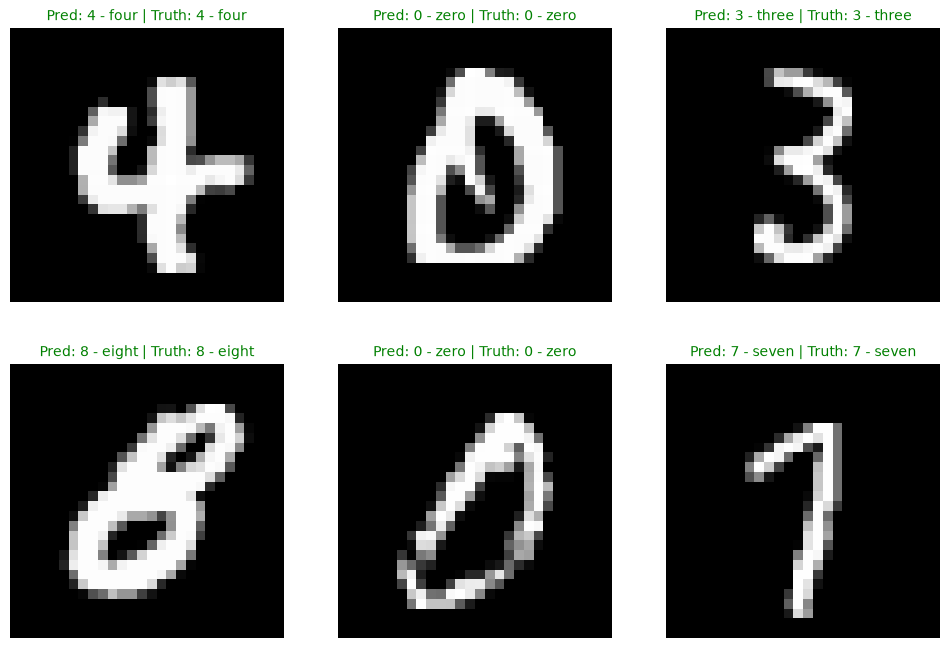

In [78]:
import random
plt.figure(figsize=(12, 8))
random_indices = random.sample(range(len(test_data)), k=6)
for i, idx in enumerate(random_indices):
    image, label = test_data[idx]
    pred_label = class_names[test_pred_tensor[idx]]
    truth_label = class_names[test_labels_tensor[idx]]
    plt.subplot(2, 3, i+1)
    plt.imshow(image.squeeze(), cmap="gray")
    title_text = f"Pred: {pred_label} | Truth: {truth_label}"
    if pred_label == truth_label:
        plt.title(title_text, fontsize=10, c="g")
    else:
        plt.title(title_text, fontsize=10, c="r")
    plt.axis(False)

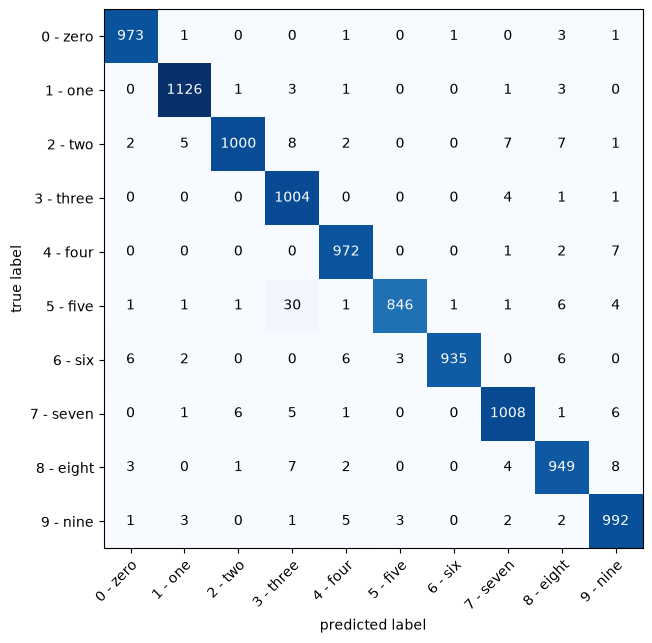

In [79]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

matrix = ConfusionMatrix(num_classes=len(class_names), task='multiclass')
confmat_tensor = matrix(preds=test_pred_tensor, target=test_labels_tensor)

fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10, 7)
)